In [67]:
import pandas as pd
import plotly.express as px
from sklearn.linear_model import LinearRegression
import numpy as np
import plotly.graph_objects as go

## Limpieza de los datos de Suministro Diario de agua por entidad Federativa año 2020

In [62]:
suministroAgua2020_2022=pd.read_csv('../data/SuministroDiarioDeAguaConeval/SIDS_AE Vi-1 RESULTADOS (3).csv',encoding='latin-1',usecols=[0,1],skiprows=1)
suministroAgua2020_2022=suministroAgua2020_2022.reset_index(drop=True)
suministroAgua2020_2022=suministroAgua2020_2022.drop([33,34,35,36,32])
suministroAgua2020_2022.columns.values[1] = 'Porcentaje de suministro diario'
suministroAgua2020_2022

,Entidad,Porcentaje de suministro diario
0,Aguascalientes,82.501699
1,Baja California,87.577967
2,Baja California Sur,17.227671
3,Campeche,55.022463
4,Coahuila,75.764865
5,Colima,82.820804
6,Chiapas,14.375526
7,Chihuahua,88.180311
8,Ciudad de México,73.543868
9,Durango,75.609462


## Limpieza de los datos de indice de rezago social

In [63]:
indiceDeRezagoSocial2020 = pd.read_excel(
    '../data/IndiceDeRezagoSocial/IRS_entidades_mpios_2020.xlsx',
    usecols=['Índice de rezago social'],
    skiprows=4,
    header=0
)
indiceDeRezagoSocial2020=indiceDeRezagoSocial2020.drop([0,1,34,35,36,37,38])
indiceDeRezagoSocial2020

,Índice de rezago social
2,-1.101561
3,-0.642387
4,-0.317027
5,0.244535
6,-1.147587
7,-0.690655
8,2.644224
9,-0.518357
10,-1.115345
11,-0.045956


## Union de los datos y comparaciones

In [64]:
suministro_vs_rezagoSocial = pd.concat([
     suministroAgua2020_2022.reset_index(drop=True),
    indiceDeRezagoSocial2020.reset_index(drop=True)
   
], axis=1)
suministro_vs_rezagoSocial

,Entidad,Porcentaje de suministro diario,Índice de rezago social
0,Aguascalientes,82.501699,-1.101561
1,Baja California,87.577967,-0.642387
2,Baja California Sur,17.227671,-0.317027
3,Campeche,55.022463,0.244535
4,Coahuila,75.764865,-1.147587
5,Colima,82.820804,-0.690655
6,Chiapas,14.375526,2.644224
7,Chihuahua,88.180311,-0.518357
8,Ciudad de México,73.543868,-1.115345
9,Durango,75.609462,-0.045956


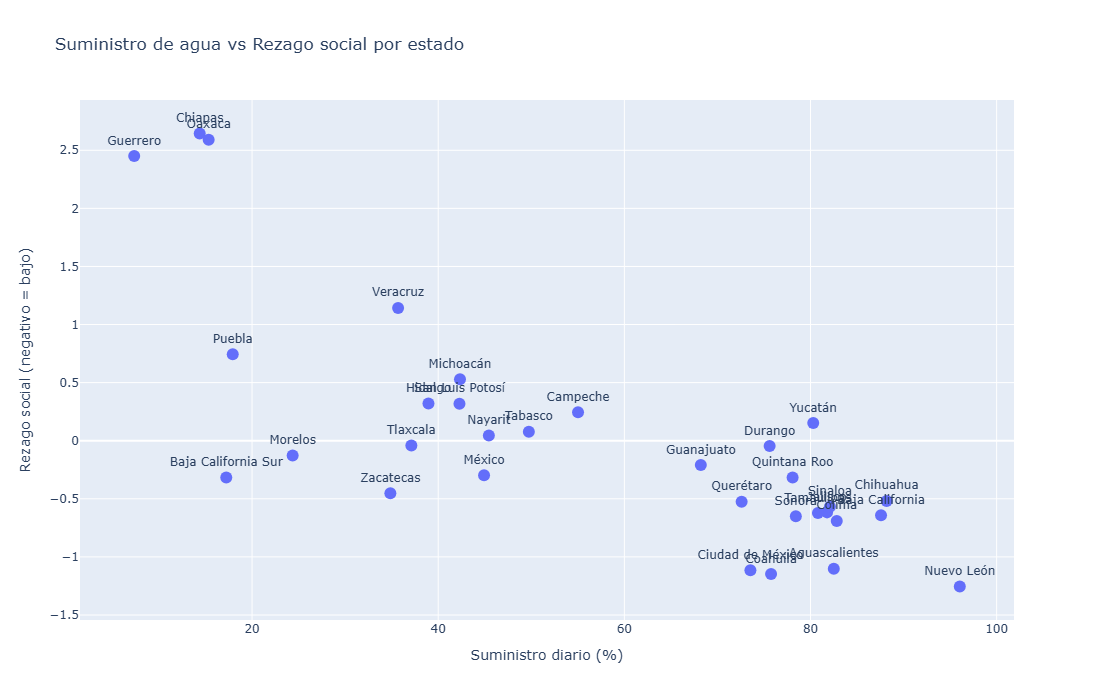

In [65]:
fig = px.scatter(
    suministro_vs_rezagoSocial,
    y='Índice de rezago social',
    x='Porcentaje de suministro diario',
    text='Entidad',          # muestra el nombre del estado sobre el punto
    hover_name='Entidad',    # al pasar el mouse también sale el nombre
    title='Suministro de agua vs Rezago social por estado',
    labels={
        'Índice de rezago social': 'Rezago social (negativo = bajo)',
        'Porcentaje de suministro diario': 'Suministro diario (%)'
    }
)

# Ajustar para que las etiquetas no se encimen (opcional)
fig.update_traces(textposition='top center', marker=dict(size=12))
fig.update_layout(width=1000, height=700)  
fig.show()

Conclusiones sobre la relación entre suministro de agua y rezago social
Con los datos reales (los primeros que me mostraste, donde Chihuahua tiene 88% y Guerrero 7%), se observa una clara tendencia: los estados con mayor rezago social, como Chiapas y Guerrero, presentan los porcentajes de suministro diario de agua más bajos. En cambio, entidades con rezago social negativo (bajo rezago), como Coahuila, Aguascalientes y Chihuahua, alcanzan suministros superiores al 75%. Esta relación inversa sugiere que la desigualdad social está asociada a un menor acceso al agua potable.

Sin embargo, existen excepciones que enriquecen el análisis. Baja California Sur, a pesar de tener un rezago social bajo (-0.32), registra solo un 17% de suministro. Esto indica que factores geográficos y climáticos (la aridez de la región) pueden limitar el acceso al agua independientemente del nivel de desarrollo social. Por otro lado, la Ciudad de México, con un rezago bajo (-1.11), alcanza un 73.5% de suministro, mostrando que una buena infraestructura puede compensar la escasez natural.


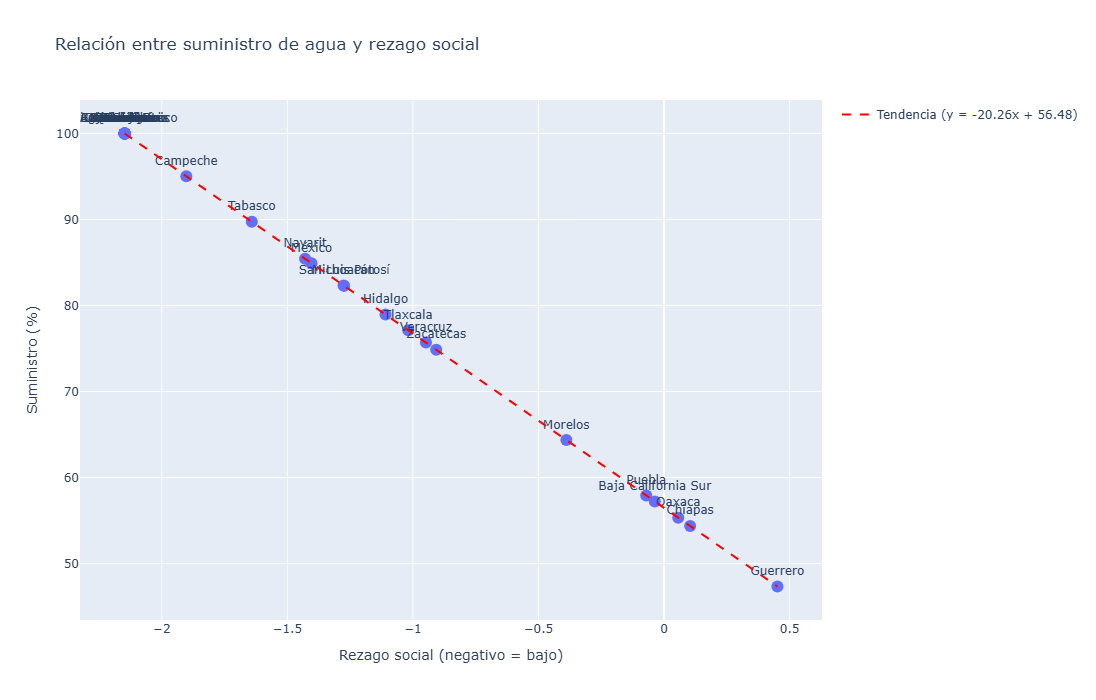

In [79]:
# Supongamos que tu DataFrame se llama df con columnas 'Índice de rezago social' y 'Porcentaje de suministro diario'
fig = px.scatter(suministro_vs_rezagoSocial, x='Índice de rezago social', y='Porcentaje de suministro diario',
                 text='Entidad', hover_name='Entidad',
                 title='Relación entre suministro de agua y rezago social',
                 labels={'Índice de rezago social': 'Rezago social (negativo = bajo)',
                         'Porcentaje de suministro diario': 'Suministro (%)'},
                 width=900, height=600)
fig.update_traces(textposition='top center', marker=dict(size=12))

# Calcular regresión lineal
X = suministro_vs_rezagoSocial[['Índice de rezago social']].values
y = suministro_vs_rezagoSocial['Porcentaje de suministro diario'].values
model = LinearRegression()
model.fit(X, y)
x_line = np.linspace(X.min(), X.max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))

fig.add_trace(go.Scatter(x=x_line, y=y_line, mode='lines',
                         name=f'Tendencia (y = {model.coef_[0]:.2f}x + {model.intercept_:.2f})',
                         line=dict(color='red', dash='dash')))
fig.update_layout(width=1000, height=700)
fig.show()

In [70]:
correlacion = suministro_vs_rezagoSocial['Índice de rezago social'].corr(suministro_vs_rezagoSocial['Porcentaje de suministro diario'])
print(f'Coeficiente de correlación de Pearson: {correlacion:.3f}')

Coeficiente de correlación de Pearson: -0.761


In [72]:
pendiente, intercepto = np.polyfit(suministro_vs_rezagoSocial['Índice de rezago social'], suministro_vs_rezagoSocial['Porcentaje de suministro diario'], 1)
print(f'Ecuación: Suministro = {pendiente:.2f} * Rezago + {intercepto:.2f}')

Ecuación: Suministro = -20.26 * Rezago + 56.48


Rezago = (56.48 - Suministro) / 20.26 entonces el rezago se puede calcular asi entonces vamos a tomar en cuenta un caso hipotetico y diremos que si se aumenta en 
en 5 años el suministro de agua a 10% entonces deberia dismunuir el reazgo social por lo tanto queria asi


In [77]:
suministro_vs_rezagoSocial['Porcentaje de suministro diario'] = (suministro_vs_rezagoSocial['Porcentaje de suministro diario'] + 10).clip(upper=100)
suministro_vs_rezagoSocial['Índice de rezago social'] = (56.48 - suministro_vs_rezagoSocial['Porcentaje de suministro diario']) / 20.26
suministro_vs_rezagoSocial

,Entidad,Porcentaje de suministro diario,Índice de rezago social
0,Aguascalientes,100.000000,-2.148075
1,Baja California,100.000000,-2.148075
2,Baja California Sur,57.227671,-0.036904
3,Campeche,95.022463,-1.902392
4,Coahuila,100.000000,-2.148075
5,Colima,100.000000,-2.148075
6,Chiapas,54.375526,0.103873
7,Chihuahua,100.000000,-2.148075
8,Ciudad de México,100.000000,-2.148075
9,Durango,100.000000,-2.148075


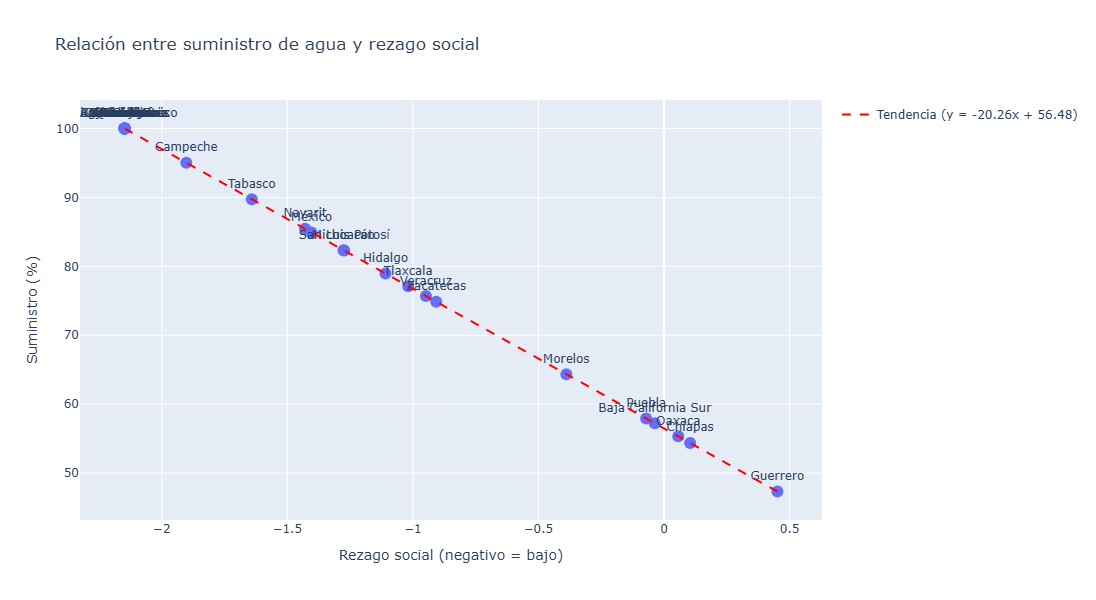

In [78]:
# Supongamos que tu DataFrame se llama df con columnas 'Índice de rezago social' y 'Porcentaje de suministro diario'
fig = px.scatter(suministro_vs_rezagoSocial, x='Índice de rezago social', y='Porcentaje de suministro diario',
                 text='Entidad', hover_name='Entidad',
                 title='Relación entre suministro de agua y rezago social',
                 labels={'Índice de rezago social': 'Rezago social (negativo = bajo)',
                         'Porcentaje de suministro diario': 'Suministro (%)'},
                 width=900, height=600)
fig.update_traces(textposition='top center', marker=dict(size=12))

# Calcular regresión lineal
X = suministro_vs_rezagoSocial[['Índice de rezago social']].values
y = suministro_vs_rezagoSocial['Porcentaje de suministro diario'].values
model = LinearRegression()
model.fit(X, y)
x_line = np.linspace(X.min(), X.max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))

fig.add_trace(go.Scatter(x=x_line, y=y_line, mode='lines',
                         name=f'Tendencia (y = {model.coef_[0]:.2f}x + {model.intercept_:.2f})',
                         line=dict(color='red', dash='dash')))
fig.show()